# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [75]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [76]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [77]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

now = Time.now()
now_ist = format_iitk(now)
now_utc = format_utc(now)

print("Time in UTC format : ", now_utc)
print("Time in IITK (IST) :", now_ist)

Time in UTC format :  2026-09-06 13:03:12 UTC
Time in IITK (IST) : 2026-09-06 18:33:12 IST




**Answer:** Two separate calls to Time.now() can return different instants because time passes between the calls.



## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_height = 2396 * u.m
wavelength = 600 * u.nm
coordinate_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_frequency = 1.4 * u.GHz
=
gtc_height_c = gtc_height.to(u.km)
wavelength_c = wavelength.to(u.THz, equivalencies=u.spectral())
coordinate_uncertainty_c = coordinate_uncertainty.to(u.arcsec)
cadence_c = cadence.to(u.hour)
radio_frequency_c = radio_frequency.to(u.cm, equivalencies=u.spectral())

print("GTC height:", gtc_height, "=", gtc_height_c)
print("Wavelength:", wavelength, "=", wavelength_c)
print("Coordinate uncertainty:", coordinate_uncertainty, "=", coordinate_uncertainty_c)
print("Cadence:", cadence, "=", cadence_c)
print("Radio frequency:", radio_frequency, "=", radio_frequency_c)







GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [79]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.


planning_start = Time(START_UTC, scale="utc")

print("Start UTC:", format_utc(planning_start))
print("Julian Date (JD):", planning_start.jd)
print("Modified Julian Date (MJD):", planning_start.mjd)
print("IIT Kanpur time:", format_iitk(planning_start))

later_time = planning_start + 2.25 * u.hour


print("UTC after 2.5 hours:", format_utc(later_time))
print("IIT Kanpur time after 2.5 hours:", format_iitk(later_time))


ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
reconstructed_time = Time(ist_datetime)

time_difference = abs((reconstructed_time - planning_start).to(u.microsecond)) #here we are able to subtract utc and ist times because astropy sees them as the very same instant

print("IST-aware Python datetime:", ist_datetime)
print("Round-trip difference:", time_difference)

assert time_difference < 1 * u.microsecond
print("Verification passed: difference is below 1 microsecond.")



Start UTC: 2026-08-30 12:00:00 UTC
Julian Date (JD): 2461283.0
Modified Julian Date (MJD): 61282.5
IIT Kanpur time: 2026-08-30 17:30:00 IST
UTC after 2.5 hours: 2026-08-30 14:15:00 UTC
IIT Kanpur time after 2.5 hours: 2026-08-30 19:45:00 IST
IST-aware Python datetime: 2026-08-30 17:30:00+05:30
Round-trip difference: 0.0 us
Verification passed: difference is below 1 microsecond.


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [80]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

frb_ra = Angle(FRB_RA_J2000)
frb_dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=frb_ra, dec=frb_dec, frame="icrs")

print(f"RA (decimal degrees): {frb_icrs.ra.deg} deg")
print(f"Dec (decimal degrees): {frb_icrs.dec.deg} deg")

print("RA (sexagesimal):", frb_icrs.ra.to_string(
    unit=u.hourangle, sep=":", pad=True, precision=2
))# COnverting to string because astropy will store an angle in the sexagecimal readable format
print("Dec (sexagesimal):", frb_icrs.dec.to_string(
    unit=u.deg, sep=":", pad=True, alwayssign=True, precision=2
))

assert np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8)
assert np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8)
print("\nVerification passed.")


RA (decimal degrees): 347.27041208333327 deg
Dec (decimal degrees): 48.70664105555556 deg
RA (sexagesimal): 23:09:04.90
Dec (sexagesimal): +48:42:23.91

Verification passed.


**Answer:** Right ascension is commonly measured in hours because the Earth completes one rotation relative to the stars in approximately 24 hours, so 24 h corresponds to \(360^\circ\). Declination is an angular distance north or south of the celestial equator, just like latitude, so it is measured in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [81]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

frb_galactic = frb_icrs.galactic
print(f"Galactic longitude, l: {frb_galactic.l.deg} deg")
print(f"Galactic latitude, b: {frb_galactic.b.deg} deg")

frb_icrs_roundtrip = frb_galactic.icrs

roundtrip_separation = frb_icrs.separation(frb_icrs_roundtrip).to(u.microarcsecond)

print("Round-trip separation:", roundtrip_separation)

Galactic longitude, l: 106.06496077332801 deg
Galactic latitude, b: -10.784176285402493 deg
Round-trip separation: 0.000310733 uarcsec


**Answer:** A tiny non-zero round-trip separation is caused by finite numerical precision in the coordinate transformation. It does not represent a physical displacement of the FRB. The change is only credited to the numerical conversion. 


## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

ecliptic_frame = BarycentricTrueEcliptic(equinox=Time("J2000"))

frb_ecliptic = frb_icrs.transform_to(ecliptic_frame)#transform_to is the key function

print(f"Ecliptic longitude, lambda: {frb_ecliptic.lon.deg} deg")
print(f"Ecliptic latitude, beta: {frb_ecliptic.lat.deg} deg")

assert 0 <= frb_ecliptic.lon.deg < 360
assert -90 <= frb_ecliptic.lat.deg <= 90#verification of ranges

frb_icrs_from_ecliptic = frb_ecliptic.icrs

roundtrip_separation_ecliptic = frb_icrs.separation(
    frb_icrs_from_ecliptic
).to(u.microarcsecond)

print("Round-trip separation:", roundtrip_separation_ecliptic)
print("Range verification passed.")

Ecliptic longitude, lambda: 14.411187650340095 deg
Ecliptic latitude, beta: 48.34695843744783 deg
Round-trip separation: 0 uarcsec
Range verification passed.


**Answer:** The ecliptic plane is the plane of Earth's orbit around the Sun, projected onto the celestial sphere. Ecliptic latitude $(\beta)$ measures the angular distance of the FRB north or south of this plane: positive values are north of the ecliptic and negative values are south of it.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [ ]:
# Construct the earlier ICRS position
earlier_ra = Angle(EARLIER_POSITION_RA)
earlier_dec = Angle(EARLIER_POSITION_DEC) #Earlier positions

earlier_position = SkyCoord(
    ra=earlier_ra,
    dec=earlier_dec,
    frame="icrs"
)

#longdouble to make sure that the small angles are handled well
alpha_1 = np.longdouble(frb_icrs.ra.to_value(u.rad))
delta_1 = np.longdouble(frb_icrs.dec.to_value(u.rad))#frb_icrs : current positions

alpha_2 = np.longdouble(earlier_position.ra.to_value(u.rad))
delta_2 = np.longdouble(earlier_position.dec.to_value(u.rad))


cos_separation = (
    np.sin(delta_1) * np.sin(delta_2)
    + np.cos(delta_1) * np.cos(delta_2) * np.cos(alpha_2 - alpha_1)
)


manual_separation = np.arccos(cos_separation) * u.rad # cos inverse

print("Manual separation:", manual_separation.to(u.arcsec))
print("Manual separation:", manual_separation.to(u.mas))

astropy_separation = frb_icrs.separation(earlier_position)

print("Astropy separation:", astropy_separation.to(u.arcsec))

difference = abs(
    manual_separation.to(u.arcsec) - astropy_separation.to(u.arcsec)
)

print("Difference:", difference)

assert difference < 1e-6 * u.arcsec
print("Verification passed: agreement is within 10^-6 arcsecond.")

Manual separation: 1.4922397272430614 arcsec
Manual separation: 1492.2397272430612 mas
Astropy separation: 1.49224 arcsec
Difference: 1.03961e-09 arcsec
Verification passed: agreement is within 10^-6 arcsecond.


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [100]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)#physical location of the GTC site

gtc_lon, gtc_lat, gtc_height = gtc_location.geodetic #geodetic contains the overall attributes of the location

print("GTC longitude:", gtc_lon)
print("GTC latitude:", gtc_lat)
print("GTC height:", gtc_height)


GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m




**Answer:** The negative longitude means GTC lies west of the Greenwich prime meridian. Its longitude is therefore $17.889^\circ$ west.



## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [ ]:

iers.conf.iers_degraded_accuracy = "warn" # Suggested by AI to avoid IERS range error

q9_time = Time("2026-08-31T00:00:00Z", scale="utc")

lst = q9_time.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)


hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(q9_time))
print("IIT Kanpur time:", format_iitk(q9_time))

print("LST:", lst.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    precision=3
))

print("Hour angle:", hour_angle.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    alwayssign=True,
    precision=3
))

# Interpret the hour-angle sign
if hour_angle.to_value(u.hourangle) < 0:
    position = "east of the meridian"
elif hour_angle.to_value(u.hourangle) > 0:
    position = "west of the meridian"
else:
    position = "transiting"

print("The target is", position + ".")

UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur time: 2026-08-31 05:30:00 IST
LST: 21:25:12.213
Hour angle: -01:43:52.686
The target is east of the meridian.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [103]:

lst_all = times.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)#list of all time values given


hour_angle_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)


transit_index = np.argmin(
    np.abs(hour_angle_all.to_value(u.hourangle))
)

nearest_transit_time = times[transit_index]
nearest_transit_lst = lst_all[transit_index]
nearest_transit_hour_angle = hour_angle_all[transit_index]

print("Nearest sampled transit index:", transit_index)
print("UTC:", format_utc(nearest_transit_time))
print("IIT Kanpur time:", format_iitk(nearest_transit_time))

print("LST:", nearest_transit_lst.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    precision=3
))

print("Hour angle:", nearest_transit_hour_angle.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    alwayssign=True,
    precision=3
))

Nearest sampled transit index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
LST: 23:05:28.640
Hour angle: -00:03:36.259


**Answer:** This is a sampled approximation because the calculation is evaluated only once every 10 minutes. The exact transit can occur between two neighbouring grid times, whereas this method chooses the recorded sample with the smallest absolute hour angle.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [87]:
predicted_transit_altitude = (
    90 * u.deg - abs(gtc_location.lat - frb_icrs.dec)
)

predicted_zenith_distance = 90 * u.deg - predicted_transit_altitude

print("Predicted upper-transit altitude:", predicted_transit_altitude.to(u.deg))
print("Predicted zenith distance:", predicted_zenith_distance.to(u.deg))

frb_altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_gtc_altaz = frb_icrs.transform_to(frb_altaz_frame)

maximum_altitude_index = np.argmax(frb_gtc_altaz.alt)

maximum_altitude = frb_gtc_altaz.alt[maximum_altitude_index]
maximum_zenith_distance = 90 * u.deg - maximum_altitude

print("\nLargest sampled Astropy altitude:", maximum_altitude.to(u.deg))
print("Its zenith distance:", maximum_zenith_distance.to(u.deg))
print("UTC:", format_utc(times[maximum_altitude_index]))
print("IST:", format_iitk(times[maximum_altitude_index]))

altitude_difference = predicted_transit_altitude - maximum_altitude

print("\nAnalytic minus largest sampled Astropy altitude:",
      altitude_difference.to(u.arcsec))


Predicted upper-transit altitude: 70d03m04.8922s
Predicted zenith distance: 19d56m55.1078s

Largest sampled Astropy altitude: 69d53m01.89937387s
Its zenith distance: 20d06m58.10062613s
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST

Analytic minus largest sampled Astropy altitude: 602.993 arcsec




**Answer:** The FRB altitude rises before meridian transit, reaches its maximum near transit, and decreases after transit as the source moves westward across the sky.



## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [88]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
sample_indices = [transit_index - 12, transit_index, transit_index + 12]

phi = gtc_location.lat.to_value(u.rad)
delta = frb_icrs.dec.to_value(u.rad)

for sample_index in sample_indices:
    current_time = times[sample_index]
    current_hour_angle = hour_angle_all[sample_index]

    H = current_hour_angle.to_value(u.rad)

    calculated_altitude = np.arcsin(
        np.sin(phi) * np.sin(delta)
        + np.cos(phi) * np.cos(delta) * np.cos(H)
    ) * u.rad

    astropy_altitude = frb_gtc_altaz.alt[sample_index]
    altitude_difference = (
        calculated_altitude.to(u.arcsec)
        - astropy_altitude.to(u.arcsec)
    )

    print()
    print("UTC:", format_utc(current_time))
    print("IST:", format_iitk(current_time))
    print("Hour angle:", current_hour_angle.to_string(
        unit=u.hourangle, sep=":", pad=True, alwayssign=True, precision=3
    ))
    print("Calculated altitude:", calculated_altitude.to(u.deg))
    print("Astropy altitude:", astropy_altitude.to(u.deg))
    print("Difference:", altitude_difference)


UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -02:03:55.971
Calculated altitude: 59.03195969452673 deg
Astropy altitude: 58d46m53.57242808s
Difference: 901.482 arcsec

UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -00:03:36.259
Calculated altitude: 70.03934798422002 deg
Astropy altitude: 69d53m01.89937387s
Difference: 559.753 arcsec

UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: +01:56:43.453
Calculated altitude: 60.06303263916696 deg
Astropy altitude: 60d09m45.20715498s
Difference: -358.29 arcsec


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [89]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg
phi = gtc_location.lat.to_value(u.rad)
delta = frb_icrs.dec.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

cos_H0 = (
    np.sin(h_min_rad) - np.sin(phi) * np.sin(delta)
) / (
    np.cos(phi) * np.cos(delta)
)

cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0 = np.arccos(cos_H0) * u.rad

H0_degrees = H0.to(u.deg)
H0_sidereal_hours = H0.to_value(u.deg) / 15

total_interval_sidereal_hours = 2 * H0_sidereal_hours

above_20_count = np.count_nonzero(
    frb_gtc_altaz.alt >= MIN_TARGET_ALTITUDE_DEG * u.deg
)

print("Limiting hour angle H0:", H0_degrees)
print("Limiting hour angle H0:", H0_sidereal_hours, "sidereal hours")
print("Estimated total interval above 20 deg:",
      total_interval_sidereal_hours, "sidereal hours")

print("Number of grid samples above 20 deg:", above_20_count)
print("Grid-sampled duration:", (above_20_count * step).to(u.hour))

Limiting hour angle H0: 91.92747700350239 deg
Limiting hour angle H0: 6.128498466900159 sidereal hours
Estimated total interval above 20 deg: 12.256996933800318 sidereal hours
Number of grid samples above 20 deg: 74
Grid-sampled duration: 12.333333333333334 h


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [90]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float)

invalid_airmass = (
    (frb_gtc_altaz.alt <= 0 * u.deg)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)

target_airmass[invalid_airmass] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]
best_airmass_index = np.nanargmin(target_airmass)

airmass_condition = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

print("Finite airmass range:",
      np.nanmin(target_airmass), "to", np.nanmax(target_airmass))
print("Best airmass:", target_airmass[best_airmass_index])
print("Best-airmass UTC:", format_utc(times[best_airmass_index]))
print("Best-airmass IST:", format_iitk(times[best_airmass_index]))
print("Samples satisfying 1 <= X <= 2.5:",
      np.count_nonzero(airmass_condition))

Finite airmass range: 1.0649656605153943 to 55.34138132575892
Best airmass: 1.0649656605153943
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IST: 2026-08-31 07:10:00 IST
Samples satisfying 1 <= X <= 2.5: 68




**Answer:** Airmass represents the atmospheric path length along a visible line of sight. When the source is below the horizon, that line of sight passes through the Earth rather than the observable atmosphere, so the corresponding `secz` values have no physical meaning and must be excluded.



### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [91]:
with solar_system_ephemeris.set("builtin"):
    sun_coordinates = get_sun(times)
    moon_geocentric = get_body("moon", times)
    moon_topocentric = get_body("moon", times, location=gtc_location)

sun_gtc_altaz = sun_coordinates.transform_to(frb_altaz_frame)
moon_gtc_altaz = moon_topocentric.transform_to(frb_altaz_frame)

sun_altitude = sun_gtc_altaz.alt
moon_altitude = moon_gtc_altaz.alt

moon_airmass = np.asarray(moon_gtc_altaz.secz.value, dtype=float)

invalid_moon_airmass = (
    (moon_altitude <= 0 * u.deg)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
)

moon_airmass[invalid_moon_airmass] = np.nan

moon_separation = moon_gtc_altaz.separation(frb_gtc_altaz)

sun_moon_elongation = sun_coordinates.separation(moon_geocentric)

moon_illuminated_fraction = (
    1 - np.cos(sun_moon_elongation.to_value(u.rad))
) / 2

finite_conditions = (
    np.isfinite(moon_altitude.to_value(u.deg))
    & np.isfinite(moon_separation.to_value(u.deg))
    & np.isfinite(moon_illuminated_fraction)
)

bright_condition = finite_conditions & (
    (
        (moon_illuminated_fraction >= 0.70)
        & (moon_altitude > 10 * u.deg)
    )
    | (moon_separation <= 45 * u.deg)
)

dark_condition = finite_conditions & (
    (moon_altitude < 0 * u.deg)
    | (
        (moon_separation >= 90 * u.deg)
        & (moon_illuminated_fraction <= 0.25)
    )
)

moon_labels = np.full(len(times), "Unknown", dtype="U7")
moon_labels[finite_conditions] = "Gray"
moon_labels[bright_condition] = "Bright"
moon_labels[dark_condition] = "Dark"

print("Transit UTC:", format_utc(times[transit_index]))
print("Transit IST:", format_iitk(times[transit_index]))
print("Sun altitude:", sun_altitude[transit_index].to(u.deg))
print("Moon altitude:", moon_altitude[transit_index].to(u.deg))
print("Moon airmass:", moon_airmass[transit_index])
print("Moon-target separation:", moon_separation[transit_index].to(u.deg))
print("Moon illuminated fraction:",
      moon_illuminated_fraction[transit_index])
print("Moon label:", moon_labels[transit_index])

Transit UTC: 2026-08-31 01:40:00 UTC
Transit IST: 2026-08-31 07:10:00 IST
Sun altitude: -51d57m21.4919484s
Moon altitude: 59d05m45.42326564s
Moon airmass: 1.1654623009745517
Moon-target separation: 45d13m36.30986788s
Moon illuminated fraction: 0.9081719061723459
Moon label: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [92]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude_values = u.Quantity(altitude, u.deg).to_value(u.deg)
    airmass_values = np.asarray(airmass, dtype=float)
    sun_altitude_values = u.Quantity(
        sun_altitude, u.deg
    ).to_value(u.deg)
    moon_separation_values = u.Quantity(
        moon_separation, u.deg
    ).to_value(u.deg)

    arrays = [
        altitude_values,
        airmass_values,
        sun_altitude_values,
        moon_separation_values
    ]

    if any(array.ndim != 1 for array in arrays):
        raise ValueError("All inputs must be one-dimensional arrays.")

    if len({array.shape for array in arrays}) != 1:
        raise ValueError("All inputs must have equal lengths.")

    return (
        (altitude_values >= MIN_TARGET_ALTITUDE_DEG)
        & (np.isfinite(airmass_values))
        & (airmass_values >= 1)
        & (airmass_values <= MAX_AIRMASS)
        & (sun_altitude_values <= MAX_SUN_ALTITUDE_DEG)
        & (moon_separation_values >= MIN_MOON_SEPARATION_DEG)
    )


preferred_visibility = visibility(
    frb_gtc_altaz.alt,
    target_airmass,
    sun_altitude,
    moon_separation
)

altitude_condition = (
    frb_gtc_altaz.alt >= MIN_TARGET_ALTITUDE_DEG * u.deg
)

airmass_condition = (
    (np.isfinite(target_airmass))
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

sun_condition = (
    sun_altitude <= MAX_SUN_ALTITUDE_DEG * u.deg
)

moon_condition = (
    moon_separation >= MIN_MOON_SEPARATION_DEG * u.deg
)

print("Altitude-condition samples:",
      np.count_nonzero(altitude_condition))
print("Airmass-condition samples:",
      np.count_nonzero(airmass_condition))
print("Sun-condition samples:",
      np.count_nonzero(sun_condition))
print("Moon-separation-condition samples:",
      np.count_nonzero(moon_condition))
print("Combined observable samples:",
      np.count_nonzero(preferred_visibility))
print("Observable during the interval:",
      "Yes" if np.any(preferred_visibility) else "No")

Altitude-condition samples: 74
Airmass-condition samples: 68
Sun-condition samples: 51
Moon-separation-condition samples: 145
Combined observable samples: 51
Observable during the interval: Yes


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [93]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
western_time = Time("2026-08-31T06:00:00Z", scale="utc")

western_index = np.argmin(
    np.abs((times - western_time).to_value(u.s))
)

evaluation_indices = [transit_index, western_index]
evaluation_names = ["Nearest sampled transit", "Western sky"]

for name, sample_index in zip(evaluation_names, evaluation_indices):
    altitude_value = frb_gtc_altaz.alt[sample_index]
    airmass_value = target_airmass[sample_index]
    sun_altitude_value = sun_altitude[sample_index]
    moon_separation_value = moon_separation[sample_index]

    altitude_pass = (
        altitude_value >= MIN_TARGET_ALTITUDE_DEG * u.deg
    )

    airmass_pass = (
        np.isfinite(airmass_value)
        and (airmass_value >= 1)
        and (airmass_value <= MAX_AIRMASS)
    )

    sun_pass = (
        sun_altitude_value <= MAX_SUN_ALTITUDE_DEG * u.deg
    )

    moon_pass = (
        moon_separation_value >= MIN_MOON_SEPARATION_DEG * u.deg
    )

    print("\n", name)
    print("UTC:", format_utc(times[sample_index]))
    print("IST:", format_iitk(times[sample_index]))
    print("Altitude:", altitude_value.to(u.deg))
    print("Airmass:", airmass_value)
    print("Sun altitude:", sun_altitude_value.to(u.deg))
    print("Moon separation:", moon_separation_value.to(u.deg))
    print("Altitude condition:", "Pass" if altitude_pass else "Fail")
    print("Airmass condition:", "Pass" if airmass_pass else "Fail")
    print("Sun condition:", "Pass" if sun_pass else "Fail")
    print("Moon condition:", "Pass" if moon_pass else "Fail")
    print(
        "Final visibility:",
        "Pass" if preferred_visibility[sample_index] else "Fail"
    )


 Nearest sampled transit
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m01.89937387s
Airmass: 1.0649656605153943
Sun altitude: -51d57m21.4919484s
Moon separation: 45d13m36.30986788s
Altitude condition: Pass
Airmass condition: Pass
Sun condition: Pass
Moon condition: Pass
Final visibility: Pass

 Western sky
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m11.17596882s
Airmass: 1.6247615439118475
Sun altitude: -11d16m55.32153863s
Moon separation: 44d41m53.32206715s
Altitude condition: Pass
Airmass condition: Pass
Sun condition: Fail
Moon condition: Pass
Final visibility: Fail



**Answer:** Meridian transit or high altitude only provides favourable target geometry and a low airmass. It does not guarantee visibility because the Sun may not be below $-18^\circ$, the Moon may be too close to the target, or another required observing condition may fail.



# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.


Observable interval 1
UTC: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 h
Best target airmass: 1.0649656605153943
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IST: 2026-08-31 07:10:00 IST
Midpoint Moon label: Bright


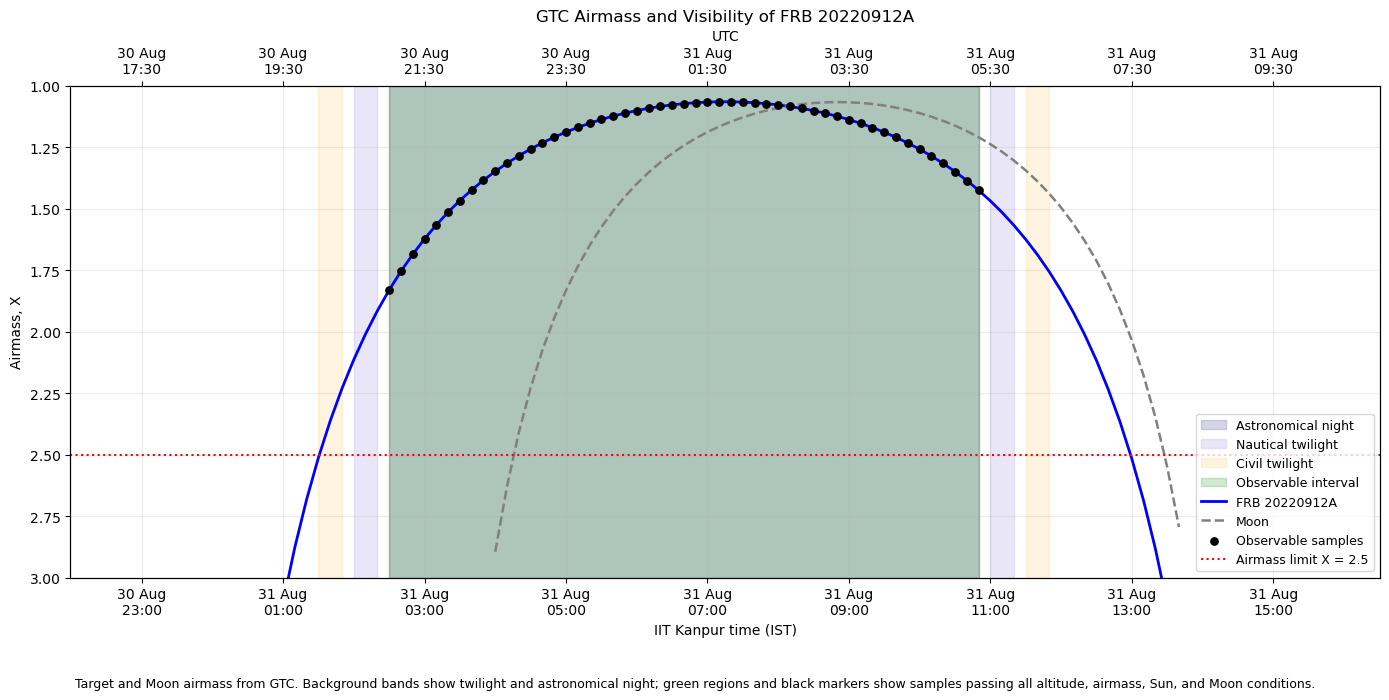


Saved figure: assignment_outputs/frb_20220912a_gtc_airmass.png
File exists and is non-empty: True
Scientific conclusion: FRB 20220912A is observable from GTC during the interval or intervals reported above.
Grid limitation: the true visibility boundaries and exact best airmass can occur between the 10-minute sample times.


In [94]:
def stitch_windows(time_values, visibility_state):
    state = np.asarray(visibility_state, dtype=bool)

    if state.ndim != 1:
        raise ValueError("visibility_state must be one-dimensional.")

    if time_values.isscalar or len(time_values) != len(state):
        raise ValueError("times and visibility_state must have equal lengths.")

    windows = []
    start_index = None

    for index, is_visible in enumerate(state):
        if is_visible and start_index is None:
            start_index = index

        if start_index is not None and (
            (not is_visible) or (index == len(state) - 1)
        ):
            end_index = index if is_visible else index - 1
            windows.append(
                (time_values[start_index], time_values[end_index])
            )
            start_index = None

    return windows


visibility_windows = stitch_windows(times, preferred_visibility)

if len(visibility_windows) == 0:
    print("No observable intervals were found.")

for window_number, (window_start, window_end) in enumerate(
    visibility_windows, start=1
):
    interval_mask = (
        (times >= window_start)
        & (times <= window_end)
    )

    interval_indices = np.where(interval_mask)[0]

    best_relative_index = np.nanargmin(
        target_airmass[interval_indices]
    )

    best_index = interval_indices[best_relative_index]

    midpoint_time = window_start + (
        window_end - window_start
    ) / 2

    midpoint_index = np.argmin(
        np.abs((times - midpoint_time).to_value(u.s))
    )

    sample_centre_duration = (
        window_end - window_start
    ).to(u.hour)

    print(f"\nObservable interval {window_number}")
    print(
        "UTC:",
        format_utc(window_start),
        "to",
        format_utc(window_end)
    )
    print(
        "IST:",
        format_iitk(window_start),
        "to",
        format_iitk(window_end)
    )
    print("Sample-centre duration:", sample_centre_duration)
    print("Best target airmass:", target_airmass[best_index])
    print("Best-airmass UTC:", format_utc(times[best_index]))
    print("Best-airmass IST:", format_iitk(times[best_index]))
    print("Midpoint Moon label:", moon_labels[midpoint_index])


plot_times = times.to_datetime(timezone=IITK_TIMEZONE)
sun_altitude_degrees = sun_altitude.to_value(u.deg)

fig, ax = plt.subplots(figsize=(14, 7))

ax.fill_between(
    plot_times,
    0,
    1,
    where=(sun_altitude_degrees <= -18),
    transform=ax.get_xaxis_transform(),
    color="midnightblue",
    alpha=0.18,
    label="Astronomical night"
)

ax.fill_between(
    plot_times,
    0,
    1,
    where=(
        (sun_altitude_degrees > -18)
        & (sun_altitude_degrees <= -12)
    ),
    transform=ax.get_xaxis_transform(),
    color="slateblue",
    alpha=0.14,
    label="Nautical twilight"
)

ax.fill_between(
    plot_times,
    0,
    1,
    where=(
        (sun_altitude_degrees > -12)
        & (sun_altitude_degrees <= -6)
    ),
    transform=ax.get_xaxis_transform(),
    color="orange",
    alpha=0.12,
    label="Civil twilight"
)

for window_number, (window_start, window_end) in enumerate(
    visibility_windows
):
    ax.axvspan(
        window_start.to_datetime(timezone=IITK_TIMEZONE),
        window_end.to_datetime(timezone=IITK_TIMEZONE),
        color="green",
        alpha=0.18,
        label="Observable interval" if window_number == 0 else None
    )

ax.plot(
    plot_times,
    target_airmass,
    color="blue",
    linestyle="-",
    linewidth=2,
    label="FRB 20220912A"
)

ax.plot(
    plot_times,
    moon_airmass,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    label="Moon"
)

ax.scatter(
    np.asarray(plot_times)[preferred_visibility],
    target_airmass[preferred_visibility],
    color="black",
    s=28,
    zorder=5,
    label="Observable samples"
)

ax.axhline(
    MAX_AIRMASS,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit X = 2.5"
)

ax.set_ylim(3, 1)
ax.set_ylabel("Airmass, X")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.set_title("GTC Airmass and Visibility of FRB 20220912A")
ax.grid(alpha=0.25)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=2, tz=IITK_TIMEZONE)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=IITK_TIMEZONE
    )
)

utc_axis = ax.twiny()
utc_axis.set_xlim(ax.get_xlim())

fig.canvas.draw()

utc_axis.set_xticks(ax.get_xticks())
utc_axis.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=timezone.utc
    )
)

utc_axis.set_xlabel("UTC")

ax.legend(loc="lower right", fontsize=9)

fig.text(
    0.5,
    0.01,
    "Target and Moon airmass from GTC. Background bands show twilight "
    "and astronomical night; green regions and black markers show samples "
    "passing all altitude, airmass, Sun, and Moon conditions.",
    ha="center",
    fontsize=9
)

fig.tight_layout(rect=[0, 0.06, 1, 1])

output_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figure:", output_path)
print(
    "File exists and is non-empty:",
    output_path.exists() and output_path.stat().st_size > 0
)

if visibility_windows:
    print(
        "Scientific conclusion: FRB 20220912A is observable from GTC "
        "during the interval or intervals reported above."
    )
else:
    print(
        "Scientific conclusion: FRB 20220912A is not observable from GTC "
        "during the specified calculation interval."
    )

print(
    "Grid limitation: the true visibility boundaries and exact best "
    "airmass can occur between the 10-minute sample times."
)

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [95]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
q19_start = Time("2026-09-01T00:00:00Z", scale="utc")
q19_end = Time("2026-09-02T00:00:00Z", scale="utc")

q19_times = q19_start + np.arange(145) * 10 * u.min

q19_altaz_frame = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

q19_frb_altaz = frb_icrs.transform_to(q19_altaz_frame)

with solar_system_ephemeris.set("builtin"):
    q19_sun = get_sun(q19_times)

q19_sun_altaz = q19_sun.transform_to(q19_altaz_frame)

q19_altitude = q19_frb_altaz.alt
q19_sun_altitude = q19_sun_altaz.alt

q19_airmass = np.asarray(q19_frb_altaz.secz.value, dtype=float)

q19_visibility = (
    (q19_altitude > 0 * u.deg)
    & (np.isfinite(q19_airmass))
    & (q19_airmass >= 1)
    & (q19_airmass <= MAX_AIRMASS)
    & (q19_sun_altitude <= MAX_SUN_ALTITUDE_DEG * u.deg)
)

q19_windows = stitch_windows(q19_times, q19_visibility)

total_visible_duration = 0 * u.hour

if len(q19_windows) == 0:
    print("No visibility interval was found.")

for window_number, (window_start, window_end) in enumerate(
    q19_windows, start=1
):
    window_duration = (window_end - window_start).to(u.hour)
    total_visible_duration += window_duration

    print(f"\nVisibility interval {window_number}")
    print(
        "UTC:",
        format_utc(window_start),
        "to",
        format_utc(window_end)
    )
    print(
        "IST:",
        format_iitk(window_start),
        "to",
        format_iitk(window_end)
    )
    print("Duration:", window_duration)

print("\nTotal visible duration:", total_visible_duration)


Visibility interval 1
UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Duration: 5.333333333333333 h

Visibility interval 2
UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Duration: 3.0 h

Total visible duration: 8.333333333333332 h


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [96]:
import imageio.v2 as imageio

q20_start = Time("2026-08-30T00:00:00Z", scale="utc")
weekly_dates = q20_start + np.arange(53) * 7 * u.day

assert weekly_dates[-1].utc.strftime("%Y-%m-%d") == "2027-08-29"

nside = 16
npix = hp.nside2npix(nside)
pixel_indices = np.arange(npix)

theta, pixel_ra = hp.pix2ang(nside, pixel_indices)
pixel_dec = (np.pi / 2) - theta

site_latitude = gtc_location.lat.to_value(u.rad)
cadence_minutes = 10
samples_per_day = 24 * 60 // cadence_minutes

visibility_maps = []

for weekly_date in weekly_dates:
    day_times = weekly_date + (
        np.arange(samples_per_day) * cadence_minutes * u.min
    )

    daily_lst = day_times.sidereal_time(
        "apparent",
        longitude=gtc_location.lon
    ).to_value(u.rad)

    hour_angle_grid = (
        daily_lst[:, np.newaxis]
        - pixel_ra[np.newaxis, :]
    )

    sin_altitude = (
        np.sin(site_latitude) * np.sin(pixel_dec)[np.newaxis, :]
        + np.cos(site_latitude)
        * np.cos(pixel_dec)[np.newaxis, :]
        * np.cos(hour_angle_grid)
    )

    sin_altitude = np.clip(sin_altitude, -1.0, 1.0)
    altitude_grid = np.arcsin(sin_altitude)

    airmass_grid = np.full_like(altitude_grid, np.nan)

    above_horizon = altitude_grid > 0

    airmass_grid[above_horizon] = (
        1 / np.sin(altitude_grid[above_horizon])
    )

    day_altaz_frame = AltAz(
        obstime=day_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    with solar_system_ephemeris.set("builtin"):
        daily_sun = get_sun(day_times)

    daily_sun_altitude = daily_sun.transform_to(
        day_altaz_frame
    ).alt.to_value(u.deg)

    astronomical_night = (
        daily_sun_altitude <= MAX_SUN_ALTITUDE_DEG
    )

    visible_grid = (
        (above_horizon)
        & (np.isfinite(airmass_grid))
        & (airmass_grid >= 1)
        & (airmass_grid <= MAX_AIRMASS)
        & (astronomical_night[:, np.newaxis])
    )

    visible_hours = (
        np.count_nonzero(visible_grid, axis=0)
        * cadence_minutes
        / 60
    )

    visibility_maps.append(visible_hours)

visibility_maps = np.asarray(visibility_maps)

frame_directory = OUTPUT_DIR / "gtc_visibility_frames"
frame_directory.mkdir(parents=True, exist_ok=True)

colour_maximum = max(
    1,
    np.ceil(np.nanmax(visibility_maps))
)

frame_paths = []

for frame_number, weekly_date in enumerate(weekly_dates):
    date_label = weekly_date.utc.strftime("%Y-%m-%d")

    figure = plt.figure(figsize=(12, 7))

    hp.mollview(
        visibility_maps[frame_number],
        fig=figure.number,
        coord="C",
        flip="astro",
        nest=False,
        min=0,
        max=colour_maximum,
        cmap="viridis",
        unit="Visible time (hours)",
        title=f"GTC All-Sky Visibility — {date_label} UTC",
        xsize=1200
    )

    hp.graticule(
        dpar=30,
        dmer=30,
        color="white",
        alpha=0.35
    )

    frame_path = (
        frame_directory
        / f"gtc_visibility_{frame_number:02d}_{date_label}.png"
    )

    plt.savefig(
        frame_path,
        dpi=120,
        bbox_inches="tight"
    )

    plt.close(figure)
    frame_paths.append(frame_path)

gif_path = OUTPUT_DIR / "gtc_one_year_visibility.gif"

with imageio.get_writer(
    gif_path,
    mode="I",
    duration=0.35,
    loop=0
) as gif_writer:
    for frame_path in frame_paths:
        gif_writer.append_data(
            imageio.imread(frame_path)
        )

print("Number of weekly dates:", len(weekly_dates))
print("First date:", weekly_dates[0].utc.strftime("%Y-%m-%d"))
print("Final date:", weekly_dates[-1].utc.strftime("%Y-%m-%d"))
print("HEALPix NSIDE:", nside)
print("Number of HEALPix pixels:", npix)
print("Number of PNG frames:", len(frame_paths))
print("GIF saved:", gif_path)
print(
    "GIF exists and is non-empty:",
    gif_path.exists() and gif_path.stat().st_size > 0
)

Number of weekly dates: 53
First date: 2026-08-30
Final date: 2027-08-29
HEALPix NSIDE: 16
Number of HEALPix pixels: 3072
Number of PNG frames: 53
GIF saved: assignment_outputs/gtc_one_year_visibility.gif
GIF exists and is non-empty: True


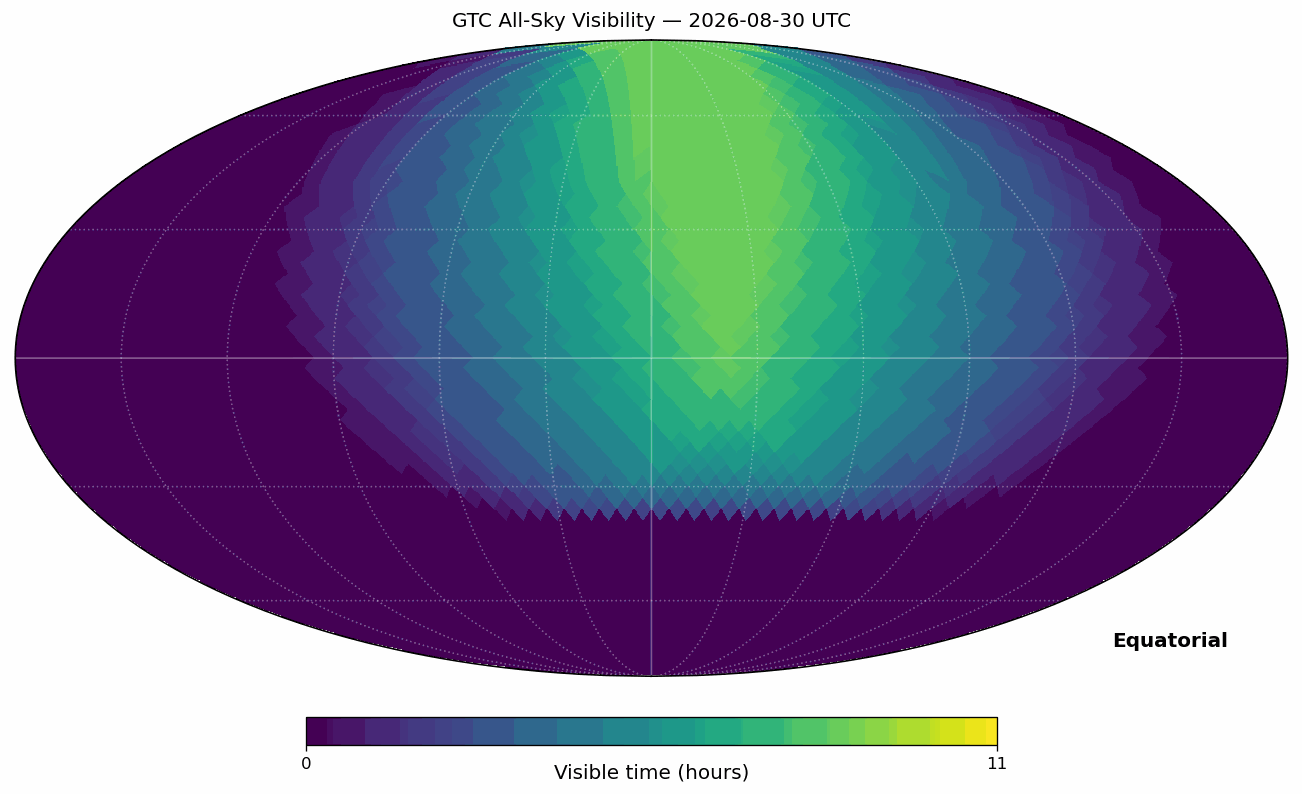

In [97]:
from IPython.display import Image, display

display(Image(filename=str(gif_path)))

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
